# 🧠 Réseaux de Neurones Convolutifs (CNN)

---

Dans ce notebook, nous allons **entraîner un Réseau de Neurones Convolutif (CNN)** pour classer des images issues du **jeu de données CIFAR-10**.

Le jeu de données **CIFAR-10** contient **60 000 images couleur** de taille 32×32 pixels, réparties en **10 classes** :
- Avion ✈️  
- Automobile 🚗  
- Oiseau 🐦  
- Chat 🐱  
- Cerf 🦌  
- Chien 🐶  
- Grenouille 🐸  
- Cheval 🐴  
- Bateau 🚢  
- Camion 🚚  

Voici ci-dessous quelques exemples d’images issues du jeu de données :

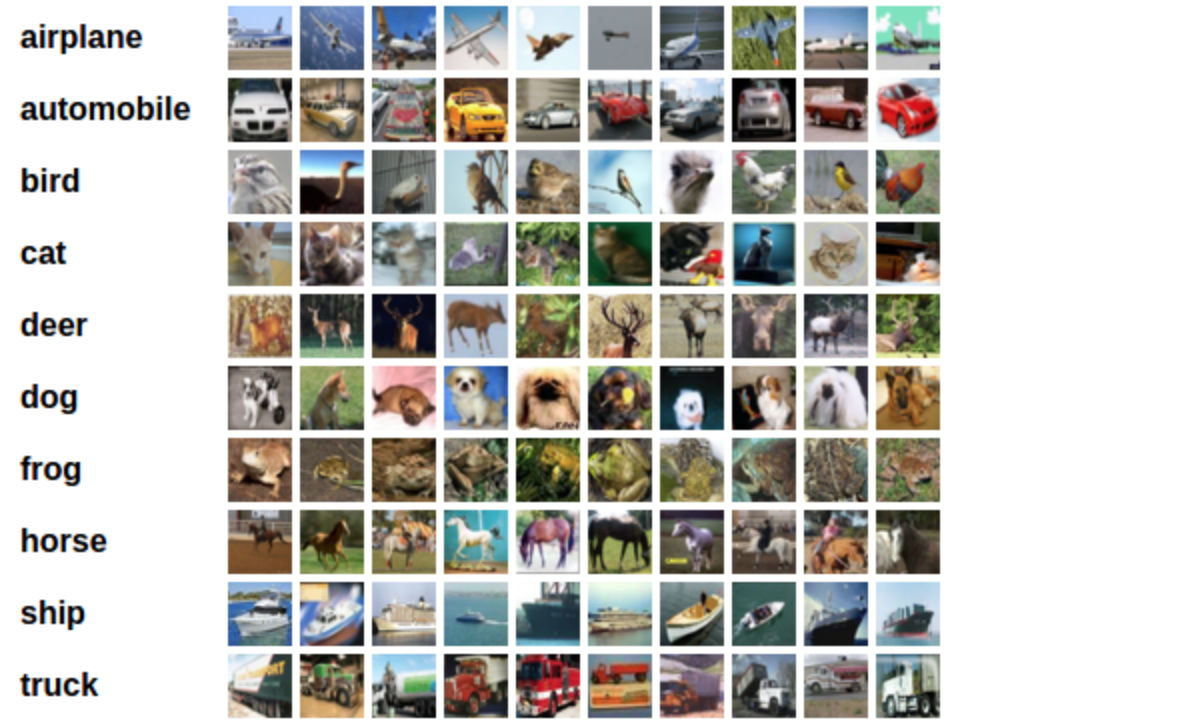

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
%cd /content/drive/MyDrive/DIT/cnn_cifar_pytorch

[WinError 3] Le chemin d’accès spécifié est introuvable: '/content/drive/MyDrive/DIT/cnn_cifar_pytorch'
c:\Users\mamad\Desktop\DIT\Deep_Learnig\conv-viz


In [6]:
%pip install pandas seaborn tqdm torchmetrics wandb -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install torchmetrics -q

In [8]:
!pip install wandb -q

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
#from livelossplot import PlotLosses
#from livelossplot.outputs import MatplotlibPlot
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import datasets
from tqdm import tqdm
import multiprocessing
# --- TorchMetrics
from torchmetrics.classification import MulticlassAccuracy, MulticlassConfusionMatrix

# --- Monitoring
import wandb


In [ ]:
cfg = {
    "project": "cifar10-torchmetrics-wandb",
    "run_name": "dit-tp",
    "batch_size": 128,
    "num_workers": multiprocessing.cpu_count(),
    "valid_size": 0.1,  # 10% of train for validation
    "lr": 1e-3,
    "epochs":   30,
    "weight_decay": 0.0,
    "model_name": "cifar_cnn",
    "save_path": "best_cifar_model.pt",
}

In [ ]:
# Restart the kernel after running this cell.
#!pip install -q -r requirements.txt -q

### Test pour [CUDA](http://pytorch.org/docs/stable/cuda.html)

Étant donné que les images utilisées ici sont de taille plus importante (32×32×3), il peut être utile d’accélérer l’entraînement en utilisant un **GPU**.  
**CUDA** est une plateforme de calcul parallèle, et les **Tenseurs CUDA** sont similaires aux Tenseurs classiques, à la différence qu’ils exploitent la puissance de calcul du GPU pour exécuter les opérations.

In [ ]:
import torch
import numpy as np

# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cuda')

---
## Charger les [Données](http://pytorch.org/docs/stable/torchvision/datasets.html)

Le téléchargement peut prendre un certain temps.  
Nous chargeons ici les données d’entraînement et de test, divisons l’ensemble d’entraînement en un sous-ensemble d’entraînement et un sous-ensemble de validation, puis créons des **DataLoaders** pour chacun de ces ensembles de données.

In [11]:
def get_train_val_data_loaders(batch_size, valid_size, transforms, num_workers):

    # Get the CIFAR10 training dataset from torchvision.datasets and set the transforms
    # We will split this further into train and validation in this function
    train_data = datasets.CIFAR10("data", train=True, download=True, transform=transforms)

    # Compute how many items we will reserve for the validation set
    n_tot = len(train_data)
    split = int(np.floor(valid_size * n_tot))

    # compute the indices for the training set and for the validation set
    shuffled_indices = torch.randperm(n_tot)
    train_idx, valid_idx = shuffled_indices[split:], shuffled_indices[:split]

    # define samplers for obtaining training and validation batches
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    # prepare data loaders (combine dataset and sampler)
    train_loader = torch.utils.data.DataLoader(
        train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers
    )
    valid_loader = torch.utils.data.DataLoader(
        train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers
    )

    return train_loader, valid_loader

In [12]:
def get_test_data_loader(batch_size, transforms, num_workers):
    # We use the entire test dataset in the test dataloader
    test_data = datasets.CIFAR10("data", train=False, download=True, transform=transforms)
    test_loader = torch.utils.data.DataLoader(
        test_data, batch_size=batch_size, num_workers=num_workers
    )

    return test_loader

In [13]:
import torchvision.transforms

#from helpers import get_train_val_data_loaders, get_test_data_loader

# Nombre de sous-processus utilisés pour le chargement des données
num_workers = multiprocessing.cpu_count()

# Nombre d’échantillons à charger par lot (batch)
batch_size = 20

# Pourcentage de l’ensemble d’entraînement utilisé pour la validation
valid_size = 0.2

# Transformation : conversion des images en tenseurs et normalisation
transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomVerticalFlip(p=0.5),
])


train_dl, valid_dl = get_train_val_data_loaders(batch_size, valid_size, transforms, num_workers)
test_dl = get_test_data_loader(batch_size, transforms, num_workers)

# Par commodité, regroupons-les dans un dictionnaire
data_loaders = {
    'train': train_dl,
    'valid': valid_dl,
    'test': test_dl
}

100.0%


In [14]:
# specify the image classes
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

### Visualize a Batch of Training Data

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline

# helper function to un-normalize and display an image
def imshow(img, sub):
    img = img / 2 + 0.5  # unnormalize
    sub.imshow(np.transpose(img, (1, 2, 0)))  # convert from Tensor image
    sub.axis("off")

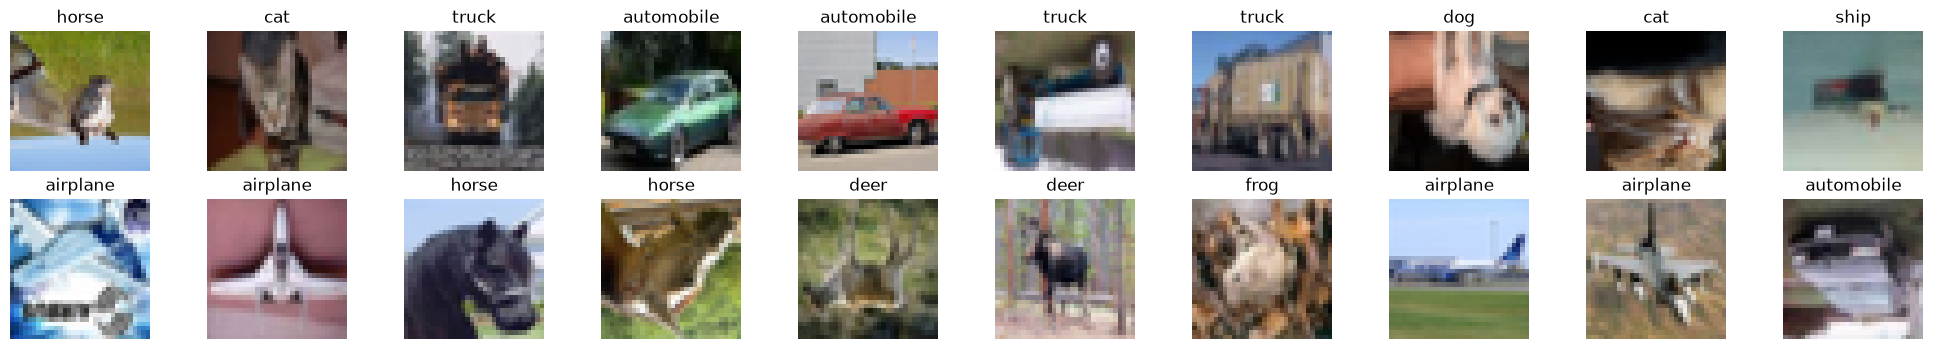

In [16]:
# obtain one batch of training images
dataiter = iter(data_loaders['train'])
images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display

# plot the images in the batch, along with the corresponding labels
# display 20 images
# NOTE: make sure your batch size is at least 20
fig, subs = plt.subplots(2, 10, figsize=(25, 4))
for i, sub in enumerate(subs.flatten()):
    imshow(images[i], sub)
    sub.set_title(classes[labels[i]])

### View an Image in More Detail

Here, we look at the normalized red, green, and blue (RGB) color channels as three separate, grayscale intensity images.

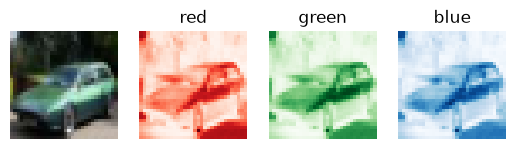

In [17]:
rgb_img = np.squeeze(images[3])
channels = ['composite', 'red', 'green', 'blue']
cmaps = [None, 'Reds', 'Greens', 'Blues']

fig, subs = plt.subplots(1, 4)

for i, sub in enumerate(subs.flatten()):

    if i == 0:
        imshow(rgb_img, sub)
    else:
        img = rgb_img[i-1]
        sub.imshow(img, cmap=cmaps[i])
        sub.set_title(channels[i])
        sub.axis("off")

---
## Définir l’[Architecture](http://pytorch.org/docs/stable/nn.html) du Réseau

Cette fois-ci, vous allez définir une architecture de **CNN**.  
Au lieu d’un MLP, qui utilise des couches linéaires entièrement connectées, vous allez utiliser :

* Des **[couches de convolution](https://pytorch.org/docs/stable/nn.html#conv2d)**, que l’on peut voir comme un empilement d’images filtrées.
* Des **[couches de maxpooling](https://pytorch.org/docs/stable/nn.html#maxpool2d)**, qui réduisent la taille spatiale (x-y) de l’entrée en conservant uniquement les pixels les plus *actifs* de la couche précédente.
* Les **couches linéaires + Dropout** habituelles pour éviter le surapprentissage et produire une sortie de dimension 10.

Un réseau comportant **2 couches de convolution** est illustré ci-dessous (et dans le code).  
Un code de départ vous est fourni avec **une** couche de convolution et **une** couche de maxpooling.

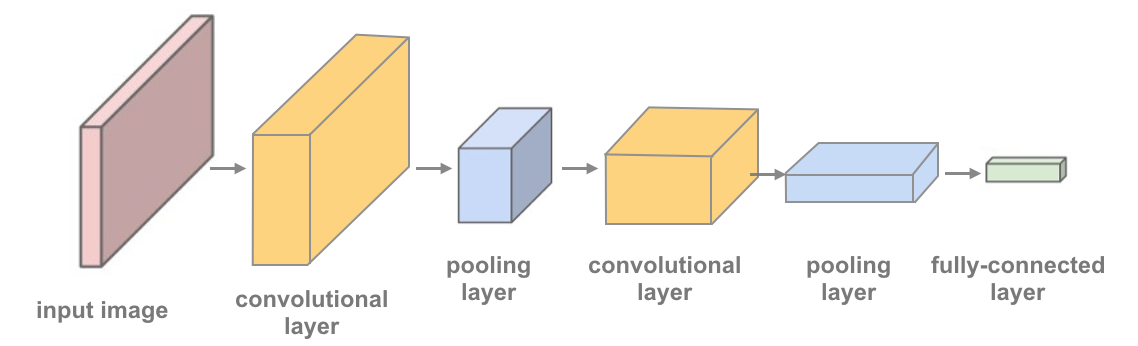

#### À FAIRE : définir un modèle avec plusieurs couches de convolution et la propagation avant (feedforward)

Plus vous incluez de couches de convolution, plus le modèle peut détecter des motifs complexes de couleur et de forme. Il est recommandé que votre modèle final comporte **2 ou 3 couches de convolution**, ainsi que des **couches linéaires** avec du **dropout** entre elles pour éviter le surapprentissage (*overfitting*).

Il est de bonne pratique de consulter la littérature et des implémentations existantes comme point de départ pour définir votre propre modèle. Vous pouvez trouver utile de regarder **[cet exemple de classification PyTorch](https://github.com/pytorch/tutorials/blob/master/beginner_source/blitz/cifar10_tutorial.py)** pour vous aider à arrêter une structure finale.

#### Volume de sortie d’une couche de convolution

Pour calculer la taille de sortie d’une couche de convolution donnée, on peut utiliser le calcul suivant (tiré du **cours cs231n de Stanford** : http://cs231n.github.io/convolutional-networks/#layers) :
> On peut calculer la taille spatiale du volume de sortie en fonction de la taille du volume d’entrée (**W**), de la taille du noyau/filtre (**F**), du **stride** (**S**) et de la quantité de **padding** (**P**) ajoutée sur les bords. La formule correcte pour le nombre de neurones définissant la dimension `output_W` est  
> **`(W − F + 2P) / S + 1`**.

Par exemple, pour une entrée **7×7** et un filtre **3×3** avec **stride = 1** et **pad = 0**, on obtient une sortie **5×5**. Avec **stride = 2**, on obtient une sortie **3×3**.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# define the CNN architecture
class Net(nn.Module):
    def __init__(self, n_classes=10):

        super(Net, self).__init__()

        # YOUR CODE HERE
        # Convolution layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # entrée: 3 canaux (RGB)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 512)   # après 3 poolings: 32→16→8→4
        self.fc2 = nn.Linear(512, 10)            # 10 classes CIFAR‑10

        # Dropout pour régularisation
        self.dropout = nn.Dropout(0.25)
    def forward(self, x):

        # YOUR CODE HERE
        # Convolutions + ReLU + Pooling
        x = self.pool(F.relu(self.conv1(x)))   # 32x32 → 16x16
        x = self.pool(F.relu(self.conv2(x)))   # 16x16 → 8x8
        x = self.pool(F.relu(self.conv3(x)))   # 8x8 → 4x4

        # Flatten
        x = x.view(-1, 128 * 4 * 4)

        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x
# create a complete CNN
model = Net()
print(model)

# move tensors to GPU if CUDA is available
if train_on_gpu:
    model.cuda()

## Combien de paramètres ?

Maintenant que vous avez construit le réseau, pouvez-vous calculer **à la main** (papier-crayon) combien de **paramètres** votre réseau contient ?  
Votre réponse correspond-elle à la sortie affichée par la cellule suivante ?

In [ ]:


sum(p.numel() for p in model.parameters() if p.requires_grad)

541094

## Visualize your network (optional)

You can visualize your achitecture by using netron.app. Just execute the following cell (which will save the network to a file called "cifar10_network.pt" in this directory), then download the produced `cifar10_network.pt` to your computer. Finally, go to [Netron.app](https://netron.app) and click on `Open Model`, and select the file you just downloaded.

In [ ]:
scripted = torch.jit.script(model)
torch.jit.save(scripted, "cifar10_network.pt")

### Specify [Loss Function](http://pytorch.org/docs/stable/nn.html#loss-functions) and [Optimizer](http://pytorch.org/docs/stable/optim.html)

Decide on a loss and optimization function that is best suited for this classification task. The linked code examples from above, may be a good starting point; [this PyTorch classification example](https://github.com/pytorch/tutorials/blob/master/beginner_source/blitz/cifar10_tutorial.py). Pay close attention to the value for **learning rate** as this value determines how your model converges to a small error.

#### TODO: Define the loss and optimizer and see how these choices change the loss over time.

In [ ]:
import torch.optim as optim

# specify loss function (categorical cross-entropy)
loss = # YOUR CODE HERE

# specify optimizer
optimizer = # YOUR CODE HERE

In [ ]:
# TorchMetrics
train_acc = MulticlassAccuracy(num_classes=len(classes)).to(device)
valid_acc = MulticlassAccuracy(num_classes=len(classes)).to(device)
test_acc = MulticlassAccuracy(num_classes=len(classes)).to(device)

---
## Train the Network

Remember to look at how the training and validation loss decreases over time; if the validation loss ever increases it indicates possible overfitting. (In fact, in the below example, we could have stopped around epoch 33 or so!)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, acc_metric):
    model.train()
    acc_metric.reset()
    running_loss = 0.0

    for imgs, targets in tqdm(loader, desc="Train", ncols=80):
        imgs, targets = imgs.to(device), targets.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(logits, dim=1)
        acc_metric.update(preds, targets)

    epoch_loss = running_loss / len(loader.sampler)
    epoch_acc = acc_metric.compute().item()
    return epoch_loss, epoch_acc

In [ ]:
def evaluate(model, loader, criterion, acc_metric):
    model.eval()
    acc_metric.reset()
    running_loss = 0.0

    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Valid", ncols=80):
            imgs, targets = imgs.to(device), targets.to(device)
            logits = model(imgs)
            loss = criterion(logits, targets)
            running_loss += loss.item() * imgs.size(0)

            preds = torch.argmax(logits, dim=1)
            acc_metric.update(preds, targets)

    epoch_loss = running_loss / len(loader.sampler)
    epoch_acc = acc_metric.compute().item()
    return epoch_loss, epoch_acc

In [ ]:
def test_and_confusion(model, loader, num_classes: int):
    model.eval()
    cm_metric = MulticlassConfusionMatrix(num_classes=num_classes).to(device)
    test_acc.reset()
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Test", ncols=80):
            imgs, targets = imgs.to(device), targets.to(device)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1)
            cm_metric.update(preds, targets)
            test_acc.update(preds, targets)

    cm = cm_metric.compute().cpu().numpy()
    acc = test_acc.compute().item()
    print(f"\n Test Accuracy : {acc:0.2f}")
    return cm

In [ ]:
# Init W&B
wandb.init(project=cfg["project"], name=cfg["run_name"], config=cfg)

In [ ]:


# Track gradients and model graph (optional, simple)
wandb.watch(model, log="gradients", log_freq=100)

best_val = float("inf")

# Define a local path to save the model checkpoint
local_save_path = "best_local.pt"

for epoch in range(1, cfg["epochs"] + 1):
    tr_loss, tr_acc = train_one_epoch(model, data_loaders["train"], criterion, optimizer, train_acc)
    val_loss, val_acc = evaluate(model, data_loaders["valid"], criterion, valid_acc)

    wandb.log({
        "epoch": epoch,
        "train/loss": tr_loss,
        "train/acc": tr_acc,
        "val/loss": val_loss,
        "val/acc": val_acc,
        "lr": optimizer.param_groups[0]["lr"],
    })

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} train accuracy {tr_acc:.4f} | val loss {val_loss:.4f} val accuracy {val_acc:.4f}")

    # Save best checkpoint on val loss locally
    if val_loss < best_val:
        best_val = val_loss
        print("Enregistrement d'un nouveau best model  !")
        torch.save( model.state_dict(), local_save_path)
        # Use wandb.save with the local path
        #wandb.save(local_save_path)

###  Load the Model with the Lowest Validation Loss

In [ ]:
model.load_state_dict(torch.load('best_local.pt'))

<All keys matched successfully>

In [ ]:
# Final test + confusion matrix
print("\nEvaluating on test set …")
cm = test_and_confusion(model, data_loaders["test"], num_classes=len(classes))


Evaluating on test set …


Test: 100%|███████████████████████████████████| 500/500 [00:05<00:00, 96.93it/s]


 Test Accuracy : 0.74


In [ ]:
def plot_confusion_matrix(cm, classes):

    #gt = pd.Series(truth, name='Ground Truth')
    #predicted = pd.Series(pred, name='Predicted')

    confusion_matrix = pd.DataFrame(cm) #pd.crosstab(gt, predicted)
    confusion_matrix.index = classes
    confusion_matrix.columns = classes

    fig, sub = plt.subplots()
    with sns.plotting_context("notebook"):

        ax = sns.heatmap(
            confusion_matrix,
            annot=True,
            fmt='d',
            ax=sub,
            linewidths=0.5,
            linecolor='lightgray',
            cbar=False
        )
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")

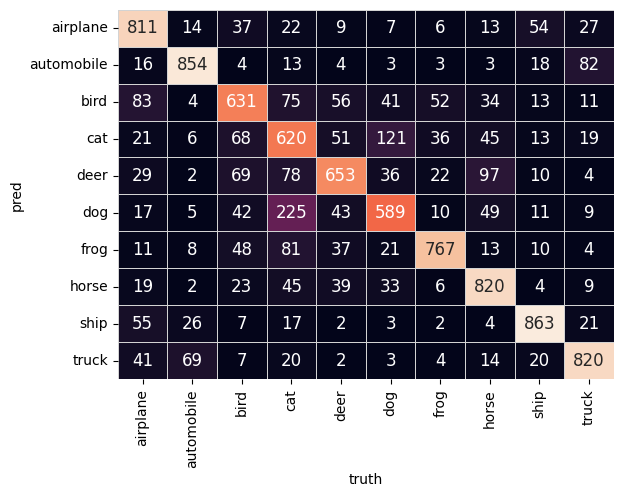

In [ ]:
plot_confusion_matrix(cm, classes)

In [ ]:
wandb.finish()

In [ ]:
cm

array([[811,  14,  37,  22,   9,   7,   6,  13,  54,  27],
       [ 16, 854,   4,  13,   4,   3,   3,   3,  18,  82],
       [ 83,   4, 631,  75,  56,  41,  52,  34,  13,  11],
       [ 21,   6,  68, 620,  51, 121,  36,  45,  13,  19],
       [ 29,   2,  69,  78, 653,  36,  22,  97,  10,   4],
       [ 17,   5,  42, 225,  43, 589,  10,  49,  11,   9],
       [ 11,   8,  48,  81,  37,  21, 767,  13,  10,   4],
       [ 19,   2,  23,  45,  39,  33,   6, 820,   4,   9],
       [ 55,  26,   7,  17,   2,   3,   2,   4, 863,  21],
       [ 41,  69,   7,  20,   2,   3,   4,  14,  20, 820]])

In [ ]:
print("Accuracy by class:\n")
for i, class_name in enumerate(classes):
    correct_predictions = cm[i][i]
    total_predictions = cm[i].sum()
    accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
    print(f"    {class_name:11s}: {accuracy:.2f}")

Accuracy by class:

    airplane   : 0.81
    automobile : 0.85
    bird       : 0.63
    cat        : 0.62
    deer       : 0.65
    dog        : 0.59
    frog       : 0.77
    horse      : 0.82
    ship       : 0.86
    truck      : 0.82


### Question : Quelles sont les faiblesses de votre modèle et comment pourraient-elles être améliorées ?

**Réponse** :  


### Visualize Sample Test Results

In [ ]:
# obtain one batch of test images
dataiter = iter(data_loaders['test'])

for i in range(2):
    images, labels = next(dataiter)
    images.numpy()

    # move model inputs to cuda, if GPU available
    if train_on_gpu:
        images = images.cuda()

    # get sample outputs
    output = model(images)
    # convert output probabilities to predicted class
    _, preds_tensor = torch.max(output, 1)
    preds = np.squeeze(preds_tensor.numpy()) if not train_on_gpu else np.squeeze(preds_tensor.cpu().numpy())

    # plot the images in the batch, along with predicted and true labels
    fig, subs = plt.subplots(2, 10, figsize=(25, 4))
    for i, ax in enumerate(subs.flatten()):
        imshow(images[i].cpu().numpy(), ax)
        ax.set_title("{} ({})".format(classes[preds[i]], classes[labels[i]]),
                     color=("green" if preds[i]==labels[i].item() else "red"))
        ax.axis("off")